In [1]:
# !pip install openpyxl ssqueezepy pyts matplotlib numpy pandas keras

In [2]:
import sys
import numpy as np

print(sys.executable)
print(np.__version__)

C:\Users\syt07\anaconda\envs\venv\python.exe
1.23.5


In [3]:
import tensorflow as tf

print(tf.__version__)
print(tf.config.list_physical_devices("GPU"))

2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
from tensorflow.python.client import device_lib 
device_lib.list_local_devices()

[name: "/device:CPU:0"
 device_type: "CPU"
 memory_limit: 268435456
 locality {
 }
 incarnation: 14788952265562687913
 xla_global_id: -1,
 name: "/device:GPU:0"
 device_type: "GPU"
 memory_limit: 5744099328
 locality {
   bus_id: 1
   links {
   }
 }
 incarnation: 185413796534630788
 physical_device_desc: "device: 0, name: NVIDIA GeForce RTX 3060 Ti, pci bus id: 0000:01:00.0, compute capability: 8.6"
 xla_global_id: 416903419]

In [5]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [6]:
import keras.models
from sklearn.model_selection import train_test_split
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns

In [7]:
import numpy as np
import pandas as pd
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt
import seaborn as sns


def load_file(filepath):
    dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
    return dataframe.values



# load a list of files and return as a 3d numpy array
def load_group(filenames, prefix=''):
    loaded = list()
    for name in filenames:
        data = load_file(prefix + name)
        loaded.append(data)
    # stack group so that features are the 3rd dimension
    loaded = np.dstack(loaded)
    return loaded

# load a dataset group, such as train or test
def load_dataset_group(group, prefix=''):
    filepath = prefix + group + '/Inertial Signals/'
    # load all 9 files as a single array
    filenames = list()
    # total acceleration
    filenames += ['total_acc_x_'+group+'.txt', 'total_acc_y_'+group+'.txt', 'total_acc_z_'+group+'.txt']
    # body acceleration
    filenames += ['body_acc_x_'+group+'.txt', 'body_acc_y_'+group+'.txt', 'body_acc_z_'+group+'.txt']
    # body gyroscope
    filenames += ['body_gyro_x_'+group+'.txt', 'body_gyro_y_'+group+'.txt', 'body_gyro_z_'+group+'.txt']
    # load input data
    X = load_group(filenames, filepath)
    # load class output
    y = load_file(prefix + group + '/y_'+group+'.txt')
    return X, y


# load the dataset, returns train and test X and y elements
# load the dataset, returns train and test X and y elements
def load_dataset(prefix=''):
    # load all train
    trainX, trainy = load_dataset_group('train', prefix + 'C:/Users/syt07/UCI HAR Dataset/')
    # load all test
    testX, testy = load_dataset_group('test', prefix + 'C:/Users/syt07/UCI HAR Dataset/')

    #zero-offset class values
    trainy = trainy - 1
    testy = testy - 1

    trainy_one_hot = to_categorical(trainy)
    testy_one_hot = to_categorical(testy)
    print(trainX.shape, trainy.shape, trainy_one_hot.shape, testX.shape, testy.shape, testy_one_hot.shape)
    return trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot

In [8]:
trainX, trainy, trainy_one_hot, testX, testy, testy_one_hot = load_dataset()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15016\4111222225.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15016\4111222225.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15016\4111222225.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15016\4111222225.py:9: FutureWarning: The 'delim_whitespace' keyw

(7352, 128, 9) (7352, 1) (7352, 6) (2947, 128, 9) (2947, 1) (2947, 6)


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_15016\4111222225.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  dataframe = pd.read_csv(filepath, header=None, delim_whitespace=True)


In [9]:
print("X train shape: ", trainX.shape)
print("Y train shape: ", trainy.shape)
print("Y train One hot shape: ", trainy_one_hot.shape)
print("X test shape: ", testX.shape)
print("Y test shape: ", testy.shape)
print("Y test One hot shape: ", testy_one_hot.shape)

X train shape:  (7352, 128, 9)
Y train shape:  (7352, 1)
Y train One hot shape:  (7352, 6)
X test shape:  (2947, 128, 9)
Y test shape:  (2947, 1)
Y test One hot shape:  (2947, 6)


In [10]:
print("0: Walking:" ,np.where(trainy == 0)[0].size)
print("1: WU:" ,np.where(trainy == 1)[0].size)
print("2: WD:" ,np.where(trainy == 2)[0].size)
print("3: Sitting:" ,np.where(trainy == 3)[0].size)
print("4: Standing:" ,np.where(trainy == 4)[0].size)
print("5: Laying:" ,np.where(trainy == 5)[0].size)

0: Walking: 1226
1: WU: 1073
2: WD: 986
3: Sitting: 1286
4: Standing: 1374
5: Laying: 1407


In [11]:
unique, counts = np.unique(trainy, return_counts=True)
print ("Train data label statistics::")
print (np.asarray((unique, counts)).T)

unique, counts = np.unique(testy, return_counts=True)
print ("Test data label statistics::")
print (np.asarray((unique, counts)).T)

Train data label statistics::
[[   0 1226]
 [   1 1073]
 [   2  986]
 [   3 1286]
 [   4 1374]
 [   5 1407]]
Test data label statistics::
[[  0 496]
 [  1 471]
 [  2 420]
 [  3 491]
 [  4 532]
 [  5 537]]


In [12]:
X_train_all = trainX   # at this stage, the data includes both dynamic and static HAR data
y_train_all = trainy

X_test_all = testX
y_test_all = testy

In [13]:
import random

static_1 = np.where(trainy == 3)[0]
static_2 = np.where(trainy == 4)[0]
static_3 = np.where(trainy == 5)[0]
static = np.concatenate([static_1, static_2, static_3])
static_list = static.tolist()

random.shuffle(static_list)

static = np.array(static_list)

trainX = X_train_all[static]
trainy = y_train_all[static]

In [14]:
static_1 = np.where(testy == 3)[0]
static_2 = np.where(testy == 4)[0]
static_3 = np.where(testy == 5)[0]
static = np.concatenate([static_1, static_2, static_3])
static_list = static.tolist()

random.shuffle(static_list)

static = np.array(static_list)

static = np.array(static_list)

testX = X_test_all[static]
testy = y_test_all[static]

In [15]:
unique, counts = np.unique(trainy, return_counts=True)
print ("Train data label statistics::")
print (np.asarray((unique, counts)).T)

unique, counts = np.unique(testy, return_counts=True)
print ("Test data label statistics::")
print (np.asarray((unique, counts)).T)

Train data label statistics::
[[   3 1286]
 [   4 1374]
 [   5 1407]]
Test data label statistics::
[[  3 491]
 [  4 532]
 [  5 537]]


In [16]:
trainy = trainy - 3
testy = testy - 3
trainy_one_hot = to_categorical(trainy)
testy_one_hot = to_categorical(testy)

In [17]:
print("X train shape: ", trainX.shape)
print("Y train shape: ", trainy.shape)
print("Y train One hot shape: ", trainy_one_hot.shape)
print("X test shape: ", testX.shape)
print("Y test shape: ", testy.shape)
print("Y test One hot shape: ", testy_one_hot.shape)

X train shape:  (4067, 128, 9)
Y train shape:  (4067, 1)
Y train One hot shape:  (4067, 3)
X test shape:  (1560, 128, 9)
Y test shape:  (1560, 1)
Y test One hot shape:  (1560, 3)


In [18]:
# trainX, valX, trainy, valy = train_test_split(trainX, trainy,test_size=0.3)

# Standard Scaling

In [19]:
from sklearn.preprocessing import StandardScaler

# Standard Scaling
scaler_std = StandardScaler()

# 데이터 평탄화 후 스케일링
trainX_flat_std = trainX.reshape(-1, 9)
testX_flat_std = testX.reshape(-1, 9)

trainX_std = scaler_std.fit_transform(trainX_flat_std)
testX_std = scaler_std.transform(testX_flat_std)

# 원래 형태로 변환
trainX_std = trainX_std.reshape(4067, 128, 9)
testX_std = testX_std.reshape(1560, 128, 9)

print("Standard Scaled trainX shape:", trainX_std.shape)
print("Standard Scaled testX shape:", testX_std.shape)

Standard Scaled trainX shape: (4067, 128, 9)
Standard Scaled testX shape: (1560, 128, 9)


In [20]:
trainX_transformer = trainX_std.copy()
testX_transformer = testX_std.copy()

In [21]:
# from tensorflow.keras import layers, models
# import tensorflow as tf

# def reshape_to_transformer_input(data):
#     """
#     데이터 형태를 Transformer 입력에 맞게 조정
#     Input: (None, 128, 9)
#     Output: (None, 128, 256)
#     """
#     input_layer = layers.Input(shape=(128, 9))
#     x = layers.Conv1D(filters=256, kernel_size=3, strides=1, padding='same')(input_layer)
#     x = layers.LayerNormalization()(x)

#     model = tf.keras.Model(inputs=input_layer, outputs=x)
#     return model(data).numpy()

# # 데이터 변환
# trainX_transformer = reshape_to_transformer_input(trainX_minmax)
# testX_transformer = reshape_to_transformer_input(testX_minmax)

# print("Transformer-ready trainX shape:", trainX_transformer.shape)  # (4067, 128, 256)
# print("Transformer-ready testX shape:", testX_transformer.shape)    # (1560, 128, 256)

# ResNet 입력 형태 변환

In [22]:
# ResNet 입력 형태로 변환
trainX_resnet = trainX_std[..., np.newaxis]  # 마지막 축에 채널 추가
testX_resnet = testX_std[..., np.newaxis]    # 마지막 축에 채널 추가

print("ResNet trainX shape:", trainX_resnet.shape)
print("ResNet testX shape:", testX_resnet.shape)

ResNet trainX shape: (4067, 128, 9, 1)
ResNet testX shape: (1560, 128, 9, 1)


# DOLG Model

In [23]:
import tensorflow as tf
from tensorflow.keras import layers

class GeneralizedMeanPooling2D(layers.Layer):
    def __init__(self, init_norm=3.0, normalize=False, epsilon=1e-4, **kwargs):
        self.init_norm = init_norm
        self.normalize = normalize
        self.epsilon = epsilon
        super(GeneralizedMeanPooling2D, self).__init__(**kwargs)

    def build(self, input_shape):
        self.p = self.add_weight(
            name="norms",
            shape=(input_shape[-1],),
            initializer=tf.keras.initializers.Constant(self.init_norm),
            trainable=True
        )
        super(GeneralizedMeanPooling2D, self).build(input_shape)

    def call(self, inputs):
        x = tf.abs(tf.maximum(self.epsilon, inputs))  # 안정성을 위해 epsilon 추가
        x = tf.pow(x, self.p)  # p승
        x = tf.reduce_mean(x, axis=[1, 2], keepdims=False)  # 평균
        x = tf.pow(x, 1.0 / self.p)  # 1/p 승

        if self.normalize:
            x = tf.nn.l2_normalize(x, axis=1)

        return x

    def get_config(self):
        config = {
            'init_norm': self.init_norm,
            'normalize': self.normalize,
            'epsilon': self.epsilon
        }
        base_config = super(GeneralizedMeanPooling2D, self).get_config()
        return dict(list(base_config.items()) + list(config.items()))


In [24]:
from tensorflow.keras import layers

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.3):
    x = inputs
    for _ in range(4):  # 4개의 Transformer Block 반복
        # Multi-Head Attention
        x_attn = layers.MultiHeadAttention(key_dim=head_size, num_heads=num_heads, dropout=dropout)(x, x)
        x = layers.Add()([x, x_attn])
        x = layers.LayerNormalization(epsilon=1e-3)(x)

        # Feed-Forward Network
        x_ff = layers.Conv1D(filters=ff_dim, kernel_size=1, activation="relu")(x)
        x_ff = layers.Dropout(dropout)(x_ff)
        x_ff = layers.Conv1D(filters=inputs.shape[-1], kernel_size=1)(x_ff)
        x = layers.Add()([x, x_ff])
        x = layers.LayerNormalization(epsilon=1e-3)(x)

    return x


In [25]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling1D, Dense, Lambda

def build_transformer_model(input_shape):
    inputs = Input(shape=input_shape)
    x = transformer_encoder(inputs, head_size=64, num_heads=4, ff_dim=128, dropout=0.3)
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(128, activation='relu')(x)
    return Model(inputs, outputs, name="TransformerEncoder")


In [26]:
def resnet_block(inputs, filters, kernel_size=3, strides=1):
    x = inputs
    for _ in range(4):  # 4개의 ResNet Block 반복
        shortcut = x
        x = layers.Conv2D(filters, kernel_size, strides=strides, padding='same')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
        x = layers.Conv2D(filters, kernel_size, strides=1, padding='same')(x)
        x = layers.BatchNormalization()(x)

        if shortcut.shape[-1] != x.shape[-1]:
            shortcut = layers.Conv2D(filters, kernel_size=1, strides=strides, padding='same')(shortcut)
            shortcut = layers.BatchNormalization()(shortcut)

        x = layers.Add()([x, shortcut])
        x = layers.ReLU()(x)

    return x


In [27]:
def build_resnet_model_with_gem(input_shape):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # ResNet Block 반복
    x = resnet_block(inputs, filters=32)
    x = resnet_block(x, filters=64)
    x = resnet_block(x, filters=128)
    x = resnet_block(x, filters=256)
    x = layers.Dropout(0.3)(x)

    # GeM 적용
    x = GeneralizedMeanPooling2D()(x)

    # Dense Layer 추가
    outputs = layers.Dense(128, activation='relu')(x)

    return tf.keras.Model(inputs, outputs, name="ResNetEncoderWithGeM")


In [28]:
class AttentionFusion(layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(name='AttentionFusion', **kwargs)
        self.attention_dense = layers.Dense(1, activation='sigmoid')  # Compute attention weight

    def call(self, inputs):
        local_feat, global_feat = inputs

        # Concatenate features and compute attention weights
        concat_feat = tf.concat([local_feat, global_feat], axis=1)
        attention_weights = self.attention_dense(concat_feat)  # Shape: (batch_size, 1)

        # Weighted sum of local and global features
        fused = attention_weights * local_feat + (1 - attention_weights) * global_feat
        return fused

In [29]:
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K

def build_dolg_model_with_l2_norm(transformer_input_shape, resnet_input_shape, num_classes):
    # 입력 레이어
    transformer_input = Input(shape=transformer_input_shape, name='Transformer_Input')
    resnet_input = Input(shape=resnet_input_shape, name='ResNet_Input')

    # Transformer Branch
    transformer_output = build_transformer_model(transformer_input_shape)(transformer_input)
    transformer_output = Lambda(lambda x: K.l2_normalize(x, axis=-1))(transformer_output)

    # ResNet Branch
    resnet_output = build_resnet_model_with_gem(resnet_input_shape)(resnet_input)
    resnet_output = Lambda(lambda x: K.l2_normalize(x, axis=-1))(resnet_output)

    # Orthogonal Fusion
    fusion_output = AttentionFusion()([transformer_output, resnet_output])
    fusion_output = Dropout(0.3)(fusion_output)
    fusion_output = Dense(128, activation='relu')(fusion_output)
    fusion_output = Lambda(lambda x: K.l2_normalize(x, axis=-1))(fusion_output)

    # Classifier
    outputs = Dense(num_classes, activation='softmax')(fusion_output)

    # 모델 생성
    model = Model(inputs=[transformer_input, resnet_input], outputs=outputs, name='DOLG_Model_with_L2_Norm')
    return model

In [30]:
import tensorflow as tf

def focal_loss(alpha=0.25, gamma=2.0):
    """
    Focal Loss 함수
    :param alpha: 클래스 가중치 조정 (기본값 0.25)
    :param gamma: 초점 조정 파라미터 (기본값 2.0)
    :return: 손실 값
    """
    def loss_fn(y_true, y_pred):
        # 예측값의 안정성을 보장하기 위해 작은 값 추가
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        # Cross-Entropy Loss 계산
        ce_loss = -y_true * tf.math.log(y_pred)

        # Focal Loss 추가
        fl_loss = alpha * tf.math.pow(1 - y_pred, gamma) * ce_loss
        return tf.reduce_mean(tf.reduce_sum(fl_loss, axis=-1))
    return loss_fn


In [31]:
# 하이퍼파라미터 설정
num_classes = 3

# DOLG 모델 구축
dolg_model = build_dolg_model_with_l2_norm((128, 9), (128, 9, 1), num_classes)

# 모델 컴파일
dolg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipvalue=1.0),
    loss=focal_loss(alpha=0.25, gamma=2.0),
    metrics=['accuracy']
)

# 모델 요약
dolg_model.summary()


Model: "DOLG_Model_with_L2_Norm"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 Transformer_Input (InputLayer)  [(None, 128, 9)]    0           []                               
                                                                                                  
 ResNet_Input (InputLayer)      [(None, 128, 9, 1)]  0           []                               
                                                                                                  
 TransformerEncoder (Functional  (None, 128)         51160       ['Transformer_Input[0][0]']      
 )                                                                                                
                                                                                                  
 ResNetEncoderWithGeM (Function  (None, 128)         5968672     ['ResNet_In

In [32]:
from tensorflow.keras.utils import plot_model

# 모델 시각화
plot_model(
    dolg_model,                   # 학습에 사용된 모델
    to_file="model_plot.png",  # 저장할 파일 이름
    show_shapes=True,         # 각 레이어의 출력 텐서 모양 표시
    show_layer_names=True,    # 레이어 이름 표시
    expand_nested=True,       # 중첩된 모델 (서브모델) 시각화
    dpi=96                    # 해상도 설정
)

You must install pydot (`pip install pydot`) and install graphviz (see instructions at https://graphviz.gitlab.io/download/) for plot_model to work.


In [33]:
trainX_transformer.shape

(4067, 128, 9)

In [34]:
trainX_resnet.shape

(4067, 128, 9, 1)

In [35]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.utils import class_weight
from tensorflow.keras.callbacks import LearningRateScheduler

def lr_schedule(epoch, lr):
    if epoch < 5:
        return lr
    return (lr * tf.math.exp(-0.05)).numpy()  # 지수 감소

lr_scheduler = LearningRateScheduler(lr_schedule)

# ReduceLROnPlateau 설정
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # 검증 손실 기준으로 동작
    factor=0.5,          # 학습률 감소 비율 (50% 감소)
    patience = 5,          # 개선되지 않을 경우 5 Epoch 후 학습률 감소
    min_lr=1e-6          # 학습률의 하한선
)

# EarlyStopping 설정
early_stopping = EarlyStopping(
    monitor='val_loss',     # 검증 손실 기준으로 조기 종료
    patience=10,            # 개선되지 않을 경우 10 Epoch 후 종료
    restore_best_weights=True  # 가장 좋은 가중치로 복원
)

# # 클래스 가중치 계산
# class_weights = class_weight.compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(np.argmax(trainy_one_hot, axis=1)),
#     y=np.argmax(trainy_one_hot, axis=1)
# )

# class_weights = {i: w for i, w in enumerate(class_weights)}
# print("Class Weights:", class_weights)

# 콜백 리스트
callbacks = [early_stopping, reduce_lr, lr_scheduler]

# 모델 학습
history = dolg_model.fit(
    [trainX_transformer, trainX_resnet],  # 입력 데이터
    trainy_one_hot,                       # 레이블
    validation_split=0.25,                # 검증 데이터 비율
    epochs=100,                          # 최대 Epoch 수
    batch_size=12,                       # 배치 사이즈
    callbacks=callbacks,                  # 콜백 리스트 추가
#     class_weight=class_weights
)

Epoch 1/100
255/255 [==============================] - 40s 115ms/step - loss: 0.0321 - accuracy: 0.8764 - val_loss: 0.0280 - val_accuracy: 0.8771 - lr: 0.0010
Epoch 2/100
255/255 [==============================] - 30s 116ms/step - loss: 0.0197 - accuracy: 0.8941 - val_loss: 0.0236 - val_accuracy: 0.8722 - lr: 0.0010
Epoch 3/100
255/255 [==============================] - 29s 112ms/step - loss: 0.0178 - accuracy: 0.8987 - val_loss: 0.0126 - val_accuracy: 0.9322 - lr: 0.0010
Epoch 4/100
255/255 [==============================] - 29s 112ms/step - loss: 0.0132 - accuracy: 0.9236 - val_loss: 0.0115 - val_accuracy: 0.9292 - lr: 0.0010
Epoch 5/100
255/255 [==============================] - 28s 112ms/step - loss: 0.0128 - accuracy: 0.9266 - val_loss: 0.0128 - val_accuracy: 0.9390 - lr: 0.0010
Epoch 6/100
255/255 [==============================] - 28s 112ms/step - loss: 0.0124 - accuracy: 0.9269 - val_loss: 0.0135 - val_accuracy: 0.9449 - lr: 9.5123e-04
Epoch 7/100
255/255 [=====================

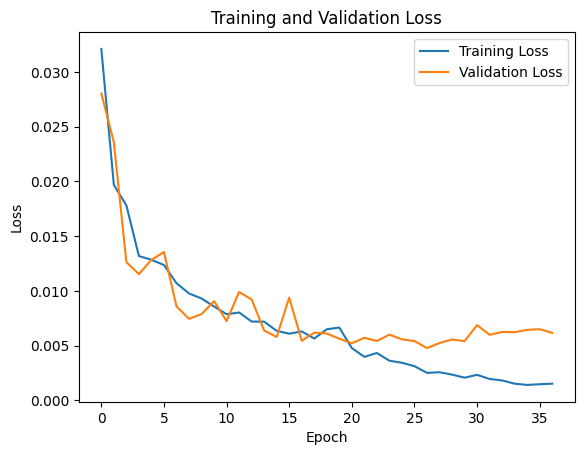

In [36]:
import matplotlib.pyplot as plt

# Plot training and validation loss

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training and Validation Loss')
plt.show()

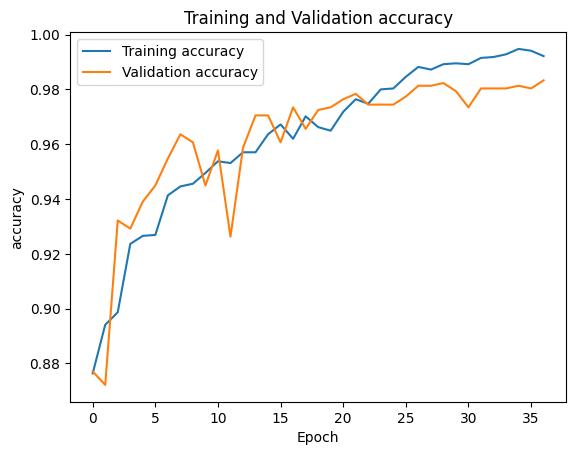

In [37]:
# Plot training and validation loss
plt.plot(history.history['accuracy'], label='Training accuracy')
plt.plot(history.history['val_accuracy'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('accuracy')
plt.legend()
plt.title('Training and Validation accuracy')
plt.show()

In [39]:
!pip install mlxtend

INFO: pip is looking at multiple versions of mlxtend to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 14.0 MB/s  0:00:00


49/49 [==============================] - 5s 88ms/step
Classification Report:
              precision    recall  f1-score   support

     SITTING       0.96      0.86      0.91       491
    STANDING       0.89      0.97      0.93       532
      LAYING       0.99      1.00      0.99       537

    accuracy                           0.94      1560
   macro avg       0.95      0.94      0.94      1560
weighted avg       0.95      0.94      0.94      1560

Test Accuracy: 0.94


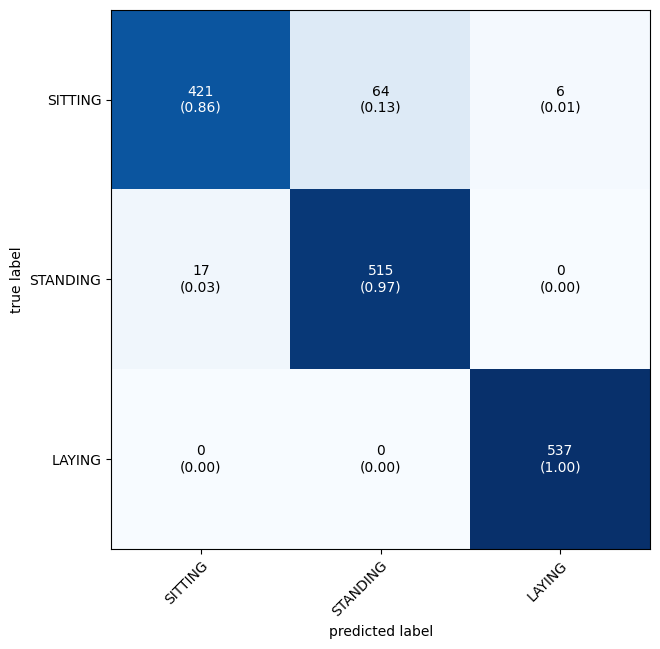

In [40]:
from mlxtend.plotting import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import numpy as np

# 예측 수행
predy = dolg_model.predict([testX_transformer, testX_resnet])
predy = np.argmax(predy, axis=-1)  # 가장 확률이 높은 클래스를 선택

# 테스트 라벨 (One-Hot Encoding → 정수형 라벨 변환)
testy = np.argmax(testy_one_hot, axis=-1)  # 테스트 레이블 변환

# 라벨 정의
LABELS = ['SITTING', 'STANDING', 'LAYING']

# 혼동 행렬 생성
cm = confusion_matrix(testy, predy)

# 혼동 행렬 시각화
plot_confusion_matrix(conf_mat=cm, class_names=LABELS, show_normed=True, figsize=(7,7))

# 성능 보고서 출력
print("Classification Report:")
print(classification_report(testy, predy, target_names=LABELS))

# 정확도 출력
accuracy = accuracy_score(testy, predy)
print(f"Test Accuracy: {accuracy:.2f}")


In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

print(cm)
print(accuracy_score(testy,predy))
print(f1_score(testy,predy, average='weighted'))
print(classification_report(testy,predy))

[[421  64   6]
 [ 17 515   0]
 [  0   0 537]]
0.9442307692307692
0.9437489020803215
              precision    recall  f1-score   support

           0       0.96      0.86      0.91       491
           1       0.89      0.97      0.93       532
           2       0.99      1.00      0.99       537

    accuracy                           0.94      1560
   macro avg       0.95      0.94      0.94      1560
weighted avg       0.95      0.94      0.94      1560



# 🔬 Ablation Study: 단일 인코더 vs 병렬(DOLG) 구조

면접 대비용. **앞의 모든 셀(데이터 로드~전처리, 모델 정의)을 먼저 실행한 뒤** 이 셀들을 실행하세요.
필요한 변수: `trainX_transformer`, `trainX_resnet`, `trainy_one_hot`, `testX`(또는 test 변환본), `testy`.

세 모델을 **동일 조건(같은 seed/콜백/Focal Loss)**으로 학습하고 정적 클래스 F1을 비교합니다.

In [42]:
# === Ablation: Single-Transformer / Single-ResNet / Parallel(DOLG) ===
# 기존에 정의된 함수 재사용: transformer_encoder, build_transformer_model,
#   build_resnet_model_with_gem, AttentionFusion, focal_loss, GeneralizedMeanPooling2D
import numpy as np, tensorflow as tf, random
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from sklearn.metrics import f1_score, accuracy_score, classification_report

NUM_CLASSES = 3
SEED = 42

def seed_all(s=SEED):
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)

# --- test 입력 준비 (train과 동일 전처리 가정) ---
# trainX_transformer: (N,128,9), trainX_resnet: (N,128,9,1)
# 아래는 test셋을 동일 형태로 맞춤. 이미 testX_transformer/testX_resnet가 있으면 그걸 쓰세요.
try:
    _ = testX_transformer.shape; _ = testX_resnet.shape
    print('using existing testX_transformer / testX_resnet')
except NameError:
    # StandardScaler 객체(scaler)가 위에서 정의됐다고 가정. 없으면 train 통계로 표준화.
    try:
        testX_std = scaler.transform(testX.reshape(-1, testX.shape[-1])).reshape(testX.shape)
    except Exception:
        mu = trainX_transformer.reshape(-1, trainX_transformer.shape[-1]).mean(0)
        sd = trainX_transformer.reshape(-1, trainX_transformer.shape[-1]).std(0) + 1e-8
        testX_std = (testX - mu) / sd
    testX_transformer = testX_std.copy()
    testX_resnet = testX_std.reshape(testX_std.shape[0], testX_std.shape[1], testX_std.shape[2], 1)
    print('built testX_transformer / testX_resnet from testX')

def make_callbacks():
    def lr_schedule(epoch, lr):
        return lr if epoch < 5 else (lr * tf.math.exp(-0.05)).numpy()
    return [
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
        LearningRateScheduler(lr_schedule),
    ]

def compile_fit(model, inputs_train, inputs_test, tag, epochs=100, batch_size=12):
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipvalue=1.0),
                  loss=focal_loss(alpha=0.25, gamma=2.0), metrics=['accuracy'])
    model.fit(inputs_train, trainy_one_hot, validation_split=0.25,
              epochs=epochs, batch_size=batch_size, callbacks=make_callbacks(), verbose=0)
    proba = model.predict(inputs_test, verbose=0)
    pred = np.argmax(proba, axis=1)
    f1 = f1_score(testy, pred, average='weighted')
    acc = accuracy_score(testy, pred)
    print(f'[{tag}] weighted F1 = {f1:.4f} | acc = {acc:.4f}')
    return {'model':tag, 'f1':round(float(f1),4), 'acc':round(float(acc),4)}

# --- 1) Single Transformer ---
def build_single_transformer(num_classes=NUM_CLASSES):
    inp = Input(shape=(128,9), name='T_in')
    x = build_transformer_model((128,9))(inp)
    x = Lambda(lambda t: K.l2_normalize(t, axis=-1))(x)
    x = Dropout(0.3)(x); x = Dense(128, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name='Single_Transformer')

# --- 2) Single ResNet ---
def build_single_resnet(num_classes=NUM_CLASSES):
    inp = Input(shape=(128,9,1), name='R_in')
    x = build_resnet_model_with_gem((128,9,1))(inp)
    x = Lambda(lambda t: K.l2_normalize(t, axis=-1))(x)
    x = Dropout(0.3)(x); x = Dense(128, activation='relu')(x)
    out = Dense(num_classes, activation='softmax')(x)
    return Model(inp, out, name='Single_ResNet')

# --- 3) Parallel (현재 채택 구조) ---
#   기존 build_dolg_model_with_l2_norm 재사용

results = []

seed_all(); results.append(compile_fit(
    build_single_transformer(), trainX_transformer, testX_transformer, 'Single Transformer'))

seed_all(); results.append(compile_fit(
    build_single_resnet(), trainX_resnet, testX_resnet, 'Single ResNet'))

seed_all(); results.append(compile_fit(
    build_dolg_model_with_l2_norm((128,9),(128,9,1),NUM_CLASSES),
    [trainX_transformer, trainX_resnet], [testX_transformer, testX_resnet], 'Parallel (DOLG)'))

# --- 결과 표 ---
import pandas as pd
df = pd.DataFrame(results)[['model','f1','acc']]
print('\n================ Ablation Result ================')
print(df.to_string(index=False))
best = df.loc[df['f1'].idxmax(),'model']
print(f'\nBest by weighted F1: {best}')


using existing testX_transformer / testX_resnet
[Single Transformer] weighted F1 = 0.9487 | acc = 0.9494
[Single ResNet] weighted F1 = 0.9297 | acc = 0.9301
[Parallel (DOLG)] weighted F1 = 0.9421 | acc = 0.9423

================ Ablation Result ================
             model     f1    acc
Single Transformer 0.9487 0.9494
     Single ResNet 0.9297 0.9301
   Parallel (DOLG) 0.9421 0.9423

Best by weighted F1: Single Transformer


## 🔬🔬 정식 Ablation: 고정 분할 + 다중 시드 (평균±표준편차)

단일 run은 분산이 커서 모델 우열을 판단할 수 없습니다. 아래 셀은:
1. **train/val 분할을 미리 고정**해 세 모델이 정확히 같은 데이터를 보게 하고,
2. **시드 3개로 반복** 학습해 평균±표준편차로 비교합니다.

→ '병렬이 평균이 높은가' 뿐 아니라 **'분산이 작아 안정적인가'**까지 볼 수 있습니다.

In [43]:
# === 정식 Ablation: 고정 분할 + 다중 시드 ===
import numpy as np, tensorflow as tf, random
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
import tensorflow.keras.backend as K
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, LearningRateScheduler
from sklearn.metrics import f1_score, accuracy_score

NUM_CLASSES = 3
SEEDS = [42, 123]

# --- test 입력 준비 (앞 셀에서 이미 만들어졌으면 그대로 사용) ---
try:
    _ = testX_transformer.shape; _ = testX_resnet.shape
except NameError:
    try:
        testX_std = scaler.transform(testX.reshape(-1, testX.shape[-1])).reshape(testX.shape)
    except Exception:
        mu = trainX_transformer.reshape(-1, trainX_transformer.shape[-1]).mean(0)
        sd = trainX_transformer.reshape(-1, trainX_transformer.shape[-1]).std(0) + 1e-8
        testX_std = (testX - mu) / sd
    testX_transformer = testX_std.copy()
    testX_resnet = testX_std.reshape(testX_std.shape[0], testX_std.shape[1], testX_std.shape[2], 1)

# --- 핵심: train/val 분할을 '미리, 한 번' 고정 (세 모델 공통) ---
N = trainX_transformer.shape[0]
rng = np.random.RandomState(0)            # 분할용 시드는 항상 0으로 고정
perm = rng.permutation(N)
val_n = int(N * 0.25)
val_idx_fixed = perm[:val_n]
tr_idx_fixed  = perm[val_n:]
print(f'Fixed split -> train {len(tr_idx_fixed)} / val {len(val_idx_fixed)} (동일 분할을 3모델 공통 사용)')

def split_inputs(X):
    return X[tr_idx_fixed], X[val_idx_fixed]

Xt_tr, Xt_va = split_inputs(trainX_transformer)
Xr_tr, Xr_va = split_inputs(trainX_resnet)
yt_tr, yt_va = trainy_one_hot[tr_idx_fixed], trainy_one_hot[val_idx_fixed]

def make_callbacks():
    def lr_schedule(epoch, lr):
        return lr if epoch < 5 else (lr * tf.math.exp(-0.05)).numpy()
    return [EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
            LearningRateScheduler(lr_schedule)]

def seed_all(s):
    random.seed(s); np.random.seed(s); tf.random.set_seed(s)

def build_single_transformer():
    inp = Input(shape=(128,9)); x = build_transformer_model((128,9))(inp)
    x = Lambda(lambda t: K.l2_normalize(t, axis=-1))(x)
    x = Dropout(0.3)(x); x = Dense(128, activation='relu')(x)
    return Model(inp, Dense(NUM_CLASSES, activation='softmax')(x), name='Single_T')
def build_single_resnet():
    inp = Input(shape=(128,9,1)); x = build_resnet_model_with_gem((128,9,1))(inp)
    x = Lambda(lambda t: K.l2_normalize(t, axis=-1))(x)
    x = Dropout(0.3)(x); x = Dense(128, activation='relu')(x)
    return Model(inp, Dense(NUM_CLASSES, activation='softmax')(x), name='Single_R')

import time
def run_once(which, seed):
    seed_all(seed)
    if which=='Single Transformer':
        m = build_single_transformer(); tr=(Xt_tr,); va=(Xt_va,); te=(testX_transformer,)
    elif which=='Single ResNet':
        m = build_single_resnet();      tr=(Xr_tr,); va=(Xr_va,); te=(testX_resnet,)
    else:
        m = build_dolg_model_with_l2_norm((128,9),(128,9,1),NUM_CLASSES)
        tr=([Xt_tr,Xr_tr],); va=([Xt_va,Xr_va],); te=([testX_transformer,testX_resnet],)
    m.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3, clipvalue=1.0),
              loss=focal_loss(alpha=0.25, gamma=2.0), metrics=['accuracy'])
    n_params = m.count_params()
    t0 = time.time()
    hist = m.fit(tr[0], yt_tr, validation_data=(va[0], yt_va),
          epochs=100, batch_size=12, callbacks=make_callbacks(), verbose=0)
    train_sec = time.time() - t0
    epochs_ran = len(hist.history['loss'])  # EarlyStopping으로 실제 돈 epoch
    pred = np.argmax(m.predict(te[0], verbose=0), axis=1)
    f1 = f1_score(testy, pred, average='weighted')
    return f1, train_sec, epochs_ran, n_params

models = ['Single Transformer', 'Single ResNet', 'Parallel (DOLG)']
import pandas as pd
rows = []
for name in models:
    scores, secs, eps = [], [], []
    n_params = None
    for s in SEEDS:
        f1, tsec, ep, npar = run_once(name, s)
        scores.append(f1); secs.append(tsec); eps.append(ep); n_params = npar
        print(f'  {name} | seed {s} | F1 {f1:.4f} | {tsec:.1f}s | {ep} epochs')
    rows.append({'model':name,
                 'mean_F1':round(np.mean(scores),4),
                 'std':round(np.std(scores),4),
                 'params':f'{n_params/1000:.0f}K',
                 'avg_sec':round(np.mean(secs),1),
                 'avg_epochs':round(np.mean(eps),1),
                 'sec_per_epoch':round(np.mean(secs)/np.mean(eps),2)})

df = pd.DataFrame(rows)
print('\n=========== Ablation (mean over', len(SEEDS), 'seeds) ===========')
print(df.to_string(index=False))
print('\n해석 가이드:')
print(' - mean_F1: 평균 성능 (높을수록 좋음)')
print(' - std: 안정성 (낮을수록 run마다 일관됨 = 병렬 구조의 기대 강점)')
print(' - params: 모델 파라미터 수 (병렬이 더 큼 = 학습 비용 증가)')
print(' - avg_sec / sec_per_epoch: 학습 소요 시간 (병렬의 비용을 정량화)')
print('\n→ 면접 포인트: 병렬이 성능 이점이 있다면, 그 대가로 파라미터/시간이')
print('   얼마나 더 드는지 trade-off를 같이 말할 수 있음.')


Fixed split -> train 3051 / val 1016 (동일 분할을 3모델 공통 사용)
  Single Transformer | seed 42 | F1 0.9342 | 93.9s | 28 epochs
  Single Transformer | seed 123 | F1 0.9420 | 90.7s | 26 epochs
  Single ResNet | seed 42 | F1 0.9256 | 1200.2s | 46 epochs
  Single ResNet | seed 123 | F1 0.9312 | 1128.6s | 44 epochs
  Parallel (DOLG) | seed 42 | F1 0.9476 | 752.8s | 27 epochs
  Parallel (DOLG) | seed 123 | F1 0.9482 | 752.9s | 27 epochs

=========== Ablation (mean over 2 seeds) ===========
             model  mean_F1    std params  avg_sec  avg_epochs  sec_per_epoch
Single Transformer   0.9381 0.0039    68K     92.3        27.0           3.42
     Single ResNet   0.9284 0.0028  5986K   1164.4        45.0          25.88
   Parallel (DOLG)   0.9479 0.0003  6037K    752.8        27.0          27.88

해석 가이드:
 - mean_F1: 평균 성능 (높을수록 좋음)
 - std: 안정성 (낮을수록 run마다 일관됨 = 병렬 구조의 기대 강점)
 - params: 모델 파라미터 수 (병렬이 더 큼 = 학습 비용 증가)
 - avg_sec / sec_per_epoch: 학습 소요 시간 (병렬의 비용을 정량화)

→ 면접 포인트: 병렬이 성능 이점이 있다면, 그 대가로 